In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# GABUNGAN DATA


# pembacaan data dari struktur SUMMARY TIF-4:
data = {
    'OLO': ['AULIANET', 'AULIANET', 'Bagusnet', 'Bnet', 'Bnet', 'Astrakom', 'Satunol', 'Satunol'],
    'STATUS': ['Layanan Existing', 'AO', 'Layanan Existing', 'Layanan Existing', 'AO', 'Layanan Existing', 'Layanan Existing', 'AO'],
    'RECORD': [47, 6, 49, 26, 1, 1, 18, 12],
    'Sum of RECURRING_RAPEL': [25000000, 3000000, 15000000, 8000000, 500000, 600000, 6340000, 2000000]
}
df_raw = pd.DataFrame(data)

In [3]:
# DATA PREPROCESSING & FEATURE ENGINEERING
print("Memproses data untuk diekstrak menjadi Fitur (X) dan Target (Y)...")

# Memisahkan data Existing (sebagai Fitur/X)
df_existing = df_raw[df_raw['STATUS'] == 'Layanan Existing'].copy()
df_existing = df_existing.rename(columns={
    'RECORD': 'Total_Layanan_Existing',
    'Sum of RECURRING_RAPEL': 'Total_MRC_Existing'
})
df_existing = df_existing[['OLO', 'Total_Layanan_Existing', 'Total_MRC_Existing']]

# Memisahkan data AO/Penambahan Baru (sebagai Target/Y)
# Jika OLO ada di dataframe ini, berarti mereka melakukan Upselling (Target = 1)
df_upsell = df_raw[df_raw['STATUS'].isin(['AO', 'Penambahan SSL Baru'])].copy()
df_upsell['Target_Upselling'] = 1
df_upsell = df_upsell[['OLO', 'Target_Upselling']].drop_duplicates()

# Menggabungkan Fitur dan Target berdasarkan OLO
df_ml = pd.merge(df_existing, df_upsell, on='OLO', how='left')

# Jika Target NaN (berarti tidak ada penambahan layanan), isi dengan 0
df_ml['Target_Upselling'] = df_ml['Target_Upselling'].fillna(0).astype(int)

print("\n--- Data Siap Latih ---")
print(df_ml.head())

Memproses data untuk diekstrak menjadi Fitur (X) dan Target (Y)...

--- Data Siap Latih ---
        OLO  Total_Layanan_Existing  Total_MRC_Existing  Target_Upselling
0  AULIANET                      47            25000000                 1
1  Bagusnet                      49            15000000                 0
2      Bnet                      26             8000000                 1
3  Astrakom                       1              600000                 0
4   Satunol                      18             6340000                 1


In [4]:
# PERSIAPAN MODEL MACHINE LEARNING
# Menentukan Variabel Independen (X) dan Dependen/Target (Y)
X = df_ml[['Total_Layanan_Existing', 'Total_MRC_Existing']]
y = df_ml['Target_Upselling']

# Membagi data menjadi Data Latih (80%) dan Data Uji (20%)
# dataset kecil, test_size disesuaikan atau gunakan cross-validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menginisiasi Model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)

# Melatih Model
print("\nMelatih model Random Forest...")
model_rf.fit(X_train, y_train)


Melatih model Random Forest...


RandomForestClassifier(max_depth=5, random_state=42)

In [5]:
# EVALUASI MODEL
# Melakukan prediksi pada data uji
y_pred = model_rf.predict(X_test)

print("\n--- Hasil Evaluasi Model ---")
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


--- Hasil Evaluasi Model ---
Akurasi: 0.0

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0




--- Tingkat Kepentingan Fitur ---
                        Importance
Total_Layanan_Existing    0.514286
Total_MRC_Existing        0.485714


/tmp/ipykernel_1006/3057395602.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances['Importance'], y=feature_importances.index, palette='viridis')


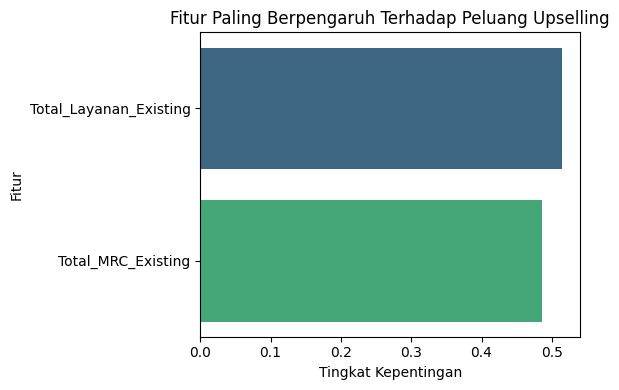

In [6]:
# MELIHAT FITUR PALING BERPENGARUH (FEATURE IMPORTANCE)
feature_importances = pd.DataFrame(
    model_rf.feature_importances_,
    index = X.columns,
    columns=['Importance']
).sort_values('Importance', ascending=False)

print("\n--- Tingkat Kepentingan Fitur ---")
print(feature_importances)

# Visualisasi (Opsional, akan muncul jika dijalankan di Jupyter/Colab)
plt.figure(figsize=(6, 4))
sns.barplot(x=feature_importances['Importance'], y=feature_importances.index, palette='viridis')
plt.title('Fitur Paling Berpengaruh Terhadap Peluang Upselling')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

In [8]:
# PREDIKSI OLO BARU
print("\n--- Simulasi Prediksi Tim Sales ---")
# Misal bulan depan ada OLO dengan 35 layanan aktif dan total tagihan 12 Juta
data_baru = pd.DataFrame({'Total_Layanan_Existing': [35], 'Total_MRC_Existing': [12000000]})
probabilitas = model_rf.predict_proba(data_baru)[0][1] # Ambil probabilitas kelas 1 (Yes)

print(f"Probabilitas OLO ini untuk menambah layanan bulan depan adalah: {probabilitas * 100:.1f}%")
if probabilitas >= 0.5:
    print("Rekomendasi: HUBUNGI SEGERA")
else:
    print("Rekomendasi: Pantau secara reguler.")


--- Simulasi Prediksi Tim Sales ---
Probabilitas OLO ini untuk menambah layanan bulan depan adalah: 96.0%
Rekomendasi: HUBUNGI SEGERA


In [9]:
# DAFTAR PRIORITAS TIM SALES (LEAD GENERATION)
print("\n--- Daftar OLO dengan Probabilitas Upselling Tertinggi ---")

# Menghitung probabilitas untuk seluruh OLO yang ada di dataset X
# [:, 1] mengambil kolom probabilitas untuk kelas 1 (Yes/Upsell)
probabilitas_semua_olo = model_rf.predict_proba(X)[:, 1]

df_prioritas = df_existing.copy()

# Menambahkan kolom hasil probabilitas dalam bentuk persentase
df_prioritas['Probabilitas (%)'] = np.round(probabilitas_semua_olo * 100, 1)

# Mengurutkan data dari probabilitas terbesar ke terkecil
df_prioritas = df_prioritas.sort_values(by='Probabilitas (%)', ascending=False)

# Menampilkan OLO teratas
print(df_prioritas.head(10).to_string(index=False))


--- Daftar OLO dengan Probabilitas Upselling Tertinggi ---
     OLO  Total_Layanan_Existing  Total_MRC_Existing  Probabilitas (%)
AULIANET                      47            25000000              99.0
Bagusnet                      49            15000000              99.0
    Bnet                      26             8000000              96.0
 Satunol                      18             6340000              92.0
Astrakom                       1              600000              29.0


#============SUMMARY============


Data tidak bisa dimuat. Pastikan file CSV yang diunggah tidak korup.
